#  Egypt Pedestrians — Enhanced Pipeline v3


-  Enhancement: denoise → histogram equalisation → sharpening only
-  YOLO crop refinement
-  Augmentation (flip / rotate / brightness)
-  EfficientNet-B2 multi-task model
-  Video animation with live feature overlay

##  Step 0 — Install Dependencies

In [1]:
!pip install ultralytics albumentations timm imageio imageio-ffmpeg --quiet
print(' Dependencies ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00
✅ Dependencies ready


##  Step 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print(' Drive mounted')

Mounted at /content/drive
✅ Drive mounted


##  Step 2 — Config + Write-Test (fixes images landing in Drive root)

In [3]:
import os
import cv2
import numpy as np

# Process all videos (no skips)
VIDEOS_TO_SKIP = set()  # Empty - process all 6 videos

# Video configurations
VIDEO_CONFIGS = [
    {'name':'V1','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V1/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V1/'},
    {'name':'V2','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V2/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V2/'},
    {'name':'V3','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V3/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V3/'},
    {'name':'V4','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V4/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V4/'},
    {'name':'V5','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V5/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V5/'},
    {'name':'V6','csv':'/content/drive/MyDrive/GIU.Master/Version 3/csv/V6/crossing_annotations.csv','frames':'/content/drive/MyDrive/GIU.Master/Version 3/Frames/V6/'},
]

# Output directory (merged structure, no per-video subfolders)
OUTPUT_ROOT = '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2'

# Feature columns - 11 total (6 original + 5 new)
# Keys are folder names, values are CSV column names (after lowercase)
FEATURE_COLUMNS = {
    # Original 6 features
    'age':                'age',
    'gender':             'gender',
    'distracted':         'distracted',
    'crossed':            'crossed',
    'judgmentcalls':      'judgmentcalls',
    'relativeposition':   'relativeposition',
    # New 5 features from CSV
    'dresscodestyle':     'dresscodestyle',
    'location':           'location',
    'fashionpersonality': 'fashionpersonality',
    'weight':             'weight',
    'disability':         'disability',
}

IMAGE_COL    = 'image_path'
TRACK_COL    = 'track_id'
MIN_CROP_PX  = 32
TARGET_SIZE  = (224, 224)
N_AUG_COPIES = 3
USE_YOLO     = True
YOLO_CONF    = 0.30
YOLO_IOU_TH  = 0.40

# Force CWD to /tmp to prevent accidental writes to Drive root
os.chdir('/tmp')

# Write test - verify OUTPUT_ROOT is writable
os.makedirs(OUTPUT_ROOT, exist_ok=True)
_test = os.path.join(OUTPUT_ROOT, '_write_test.jpg')
_ok   = cv2.imwrite(_test, np.zeros((8,8,3), np.uint8))
if not _ok or not os.path.exists(_test):
    raise RuntimeError(
        f'\nCannot write to OUTPUT_ROOT: {OUTPUT_ROOT}\n'
        'Check spelling, remount Drive, or change the path.'
    )
os.remove(_test)
print('Write test passed')
print(f'Output directory: {OUTPUT_ROOT}')
print(f'Processing all 6 videos (V1-V6)')
print(f'Features: {list(FEATURE_COLUMNS.keys())}')


Write test passed
Output directory: /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2
Processing all 6 videos (V1-V6)
Features: ['age', 'gender', 'distracted', 'crossed', 'judgmentcalls', 'relativeposition', 'dresscodestyle', 'location', 'fashionpersonality', 'weight', 'disability']


##  Step 3 — YOLOv8 Person Detector

In [4]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt') if USE_YOLO else None
print(' YOLOv8 nano loaded' if USE_YOLO else '  YOLO disabled')


def _iou(a, b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    iw=max(0,ix2-ix1); ih=max(0,iy2-iy1)
    inter=iw*ih
    if inter==0: return 0.0
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter)


def refine_with_yolo(frame, ann_box):
    if yolo_model is None: return ann_box
    res  = yolo_model(frame, verbose=False, conf=YOLO_CONF, classes=[0])
    best, best_score = ann_box, 0.0
    if res and res[0].boxes is not None:
        for d in res[0].boxes.xyxy.cpu().numpy():
            box = tuple(map(int, d[:4]))
            s   = _iou(ann_box, box)
            if s > best_score: best_score, best = s, box
    return best if best_score >= YOLO_IOU_TH else ann_box


print(' YOLO helpers ready')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 nano loaded
✅ YOLO helpers ready


##  Step 4 — Image Enhancement & Augmentation

**Enhancement (clean, non-destructive):**
1. Fast non-local means **denoising**
2. **Histogram equalisation** on luminance channel (YCrCb — no colour shift)
3. **Unsharp-mask sharpening**
4. Lanczos resize to 224×224

In [5]:
import albumentations as A


def enhance_crop(bgr):
    """
    Conservative enhancement for surveillance footage:
      1. Mild denoise (h=4)
      2. CLAHE clipLimit=1.5 on L channel (LAB colorspace)
      3. Mild unsharp mask sharpening
      4. Lanczos resize to 224x224
    """
    # Denoise
    dn = cv2.fastNlMeansDenoisingColored(
        bgr, None, h=4, hColor=4,
        templateWindowSize=7, searchWindowSize=15
    )
    # CLAHE on L channel in LAB space (preserves color)
    lab = cv2.cvtColor(dn, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(4, 4))
    l = clahe.apply(l)
    out = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    # Unsharp mask
    blur = cv2.GaussianBlur(out, (0, 0), sigmaX=1.0)
    out = cv2.addWeighted(out, 1.2, blur, -0.2, 0)
    # Resize
    return cv2.resize(out, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)


# Augmentation pipeline
# border_mode=REFLECT prevents black corner fill on rotation
# CoarseDropout removed (was creating visible black squares)
_AUG = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.6, border_mode=cv2.BORDER_REFLECT),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.12, rotate_limit=12, p=0.5,
                       border_mode=cv2.BORDER_REFLECT),
])


def augment(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return cv2.cvtColor(_AUG(image=rgb)['image'], cv2.COLOR_RGB2BGR)


def crop_from_row(frame, row):
    H, W = frame.shape[:2]
    x1 = max(0, int(float(row['xtl'])))
    y1 = max(0, int(float(row['ytl'])))
    x2 = min(W, int(float(row['xbr'])))
    y2 = min(H, int(float(row['ybr'])))
    if x2-x1 < MIN_CROP_PX or y2-y1 < MIN_CROP_PX:
        return None, None
    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)


print('Enhancement and augmentation helpers ready')


Enhancement and augmentation helpers ready


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


##  Step 5 — Main Processing Loop (merged folders, skip V2)

In [7]:
import os
import cv2
import pandas as pd
from tqdm.auto import tqdm

# Force CWD away from Drive root
os.chdir('/tmp')
print(f'CWD set to: {os.getcwd()}')

# >>> NEW: versions to skip
SKIP_VERSIONS = {"V2"}

summary_rows = []

# DEBUG: log first 3 saves to verify exact paths
debug_log = []

for video in VIDEO_CONFIGS:
    vname = video['name']

    # >>> UPDATED: skip V1 & V2
    if vname in SKIP_VERSIONS:
        print(f'Skipping {vname} (already processed)')
        continue

    # keep your existing optional skip list
    if vname in VIDEOS_TO_SKIP:
        print(f'Skipping {vname}')
        continue

    print(f'\nProcessing {vname}')

    if not os.path.exists(video['csv']):
        print(f'   WARNING: CSV not found, skipping')
        continue

    df = pd.read_csv(video['csv'])
    df.columns = df.columns.str.lower().str.strip()
    df = df.sort_values(['frame', 'track_id']).reset_index(drop=True)

    saved=0; skip_img=0; skip_crop=0; skip_write=0

    for frame_id, group in tqdm(df.groupby('frame'), desc=vname, unit='frm'):

        filename  = os.path.basename(str(group.iloc[0][IMAGE_COL]))
        img_path  = os.path.join(video['frames'], filename)

        if not os.path.exists(img_path):
            skip_img += len(group)
            continue

        frame_img = cv2.imread(img_path)
        if frame_img is None:
            skip_img += len(group)
            continue

        for _, row in group.iterrows():

            # 1. CSV crop
            raw_crop, ann_box = crop_from_row(frame_img, row)
            if raw_crop is None:
                skip_crop += 1
                continue

            # 2. YOLO refinement
            if USE_YOLO:
                H, W = frame_img.shape[:2]
                rb = refine_with_yolo(frame_img, ann_box)
                rx1=max(0,rb[0]); ry1=max(0,rb[1])
                rx2=min(W,rb[2]); ry2=min(H,rb[3])
                if rx2-rx1 >= MIN_CROP_PX and ry2-ry1 >= MIN_CROP_PX:
                    raw_crop = frame_img[ry1:ry2, rx1:rx2]

            # 3. Enhance
            enhanced  = enhance_crop(raw_crop)
            base_name = f"{vname}_t{row[TRACK_COL]}_f{int(row['frame'])}"

            for feature, col in FEATURE_COLUMNS.items():
                raw_val = row.get(col, '')
                label   = str(raw_val).lower().strip()

                # Skip empty / null / false
                if label in ('', 'nan', 'none', 'false'):
                    continue

                out_dir   = os.path.join(OUTPUT_ROOT, feature, label)
                orig_path = os.path.join(out_dir, f'{base_name}.jpg')

                try:
                    os.makedirs(out_dir, exist_ok=True)
                except Exception as e:
                    print(f'\nERROR creating dir: {out_dir}')
                    print(f'  Exception: {e}')
                    skip_write += 1
                    continue

                if not os.path.isdir(out_dir):
                    print(f'\nERROR: makedirs succeeded but dir does not exist: {out_dir}')
                    skip_write += 1
                    continue

                # Save original
                if not os.path.exists(orig_path):
                    write_ok = cv2.imwrite(orig_path, enhanced,
                                          [cv2.IMWRITE_JPEG_QUALITY, 93])

                    if not write_ok:
                        print(f'\nERROR: cv2.imwrite returned False')
                        print(f'  Path: {orig_path}')
                        skip_write += 1
                        continue

                    if not os.path.exists(orig_path):
                        print(f'\nERROR: imwrite returned True but file does not exist')
                        print(f'  Expected: {orig_path}')
                        print(f'  CWD: {os.getcwd()}')
                        fallback = os.path.join(os.getcwd(), f'{base_name}.jpg')
                        if os.path.exists(fallback):
                            print(f'  FOUND in CWD: {fallback}')
                            print(f'  This means cv2.imwrite ignored the full path!')
                        skip_write += 1
                        continue

                    saved += 1

                    if len(debug_log) < 3:
                        debug_log.append({
                            'file': orig_path,
                            'exists': os.path.exists(orig_path),
                            'size': os.path.getsize(orig_path) if os.path.exists(orig_path) else 0,
                        })

                # Save augmented copies
                for i in range(N_AUG_COPIES):
                    aug_path = os.path.join(out_dir, f'{base_name}_aug{i}.jpg')
                    if not os.path.exists(aug_path):
                        cv2.imwrite(aug_path, augment(enhanced),
                                   [cv2.IMWRITE_JPEG_QUALITY, 90])

                summary_rows.append({
                    'video': vname,
                    'frame': int(row['frame']),
                    'track_id': row[TRACK_COL],
                    'feature': feature,
                    'label': label,
                    'img_name': f'{base_name}.jpg',
                    'full_path': orig_path,
                })

    print(f'   Results: saved={saved}  skip_no_img={skip_img}  '
          f'skip_bad_crop={skip_crop}  skip_write_fail={skip_write}')

# Summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_ROOT, 'dataset_summary.csv')
summary_df.to_csv(summary_path, index=False)

print(f'\nSummary CSV saved: {summary_path}')
print(f'Total records: {len(summary_df)}')
print(f'\nDataset location: {OUTPUT_ROOT}')

# Print debug log
if debug_log:
    print('\n--- First 3 files saved (verification) ---')
    for i, entry in enumerate(debug_log, 1):
        print(f'{i}. {entry["file"]}')
        print(f'   Exists: {entry["exists"]}  Size: {entry["size"]} bytes')


CWD set to: /tmp
Skipping V1 (already processed)
Skipping V2 (already processed)

Processing V3


V3:   0%|          | 0/559 [00:00<?, ?frm/s]

   Results: saved=4824  skip_no_img=0  skip_bad_crop=23  skip_write_fail=0

Processing V4


V4:   0%|          | 0/938 [00:00<?, ?frm/s]

   Results: saved=8260  skip_no_img=648  skip_bad_crop=0  skip_write_fail=0

Processing V5


V5:   0%|          | 0/776 [00:00<?, ?frm/s]

   Results: saved=10750  skip_no_img=0  skip_bad_crop=0  skip_write_fail=0

Processing V6


V6:   0%|          | 0/132 [00:00<?, ?frm/s]

   Results: saved=1440  skip_no_img=0  skip_bad_crop=0  skip_write_fail=0

Summary CSV saved: /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/dataset_summary.csv
Total records: 25274

Dataset location: /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2

--- First 3 files saved (verification) ---
1. /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/age/adult/V3_t0_f80.jpg
   Exists: True  Size: 13041 bytes
2. /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/gender/male/V3_t0_f80.jpg
   Exists: True  Size: 13041 bytes
3. /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/distracted/no/V3_t0_f80.jpg
   Exists: True  Size: 13041 bytes


##  Step 6 — Dataset Stats & Sample Grid


📊 Class distribution

  age:
    adult                  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ 7344
    child                  ████████████████████████████████████████████████ 1464
    senior                 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ 5640
  gender:
    female                 █████████████████████████████████████████████████ 1492
    male                   ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

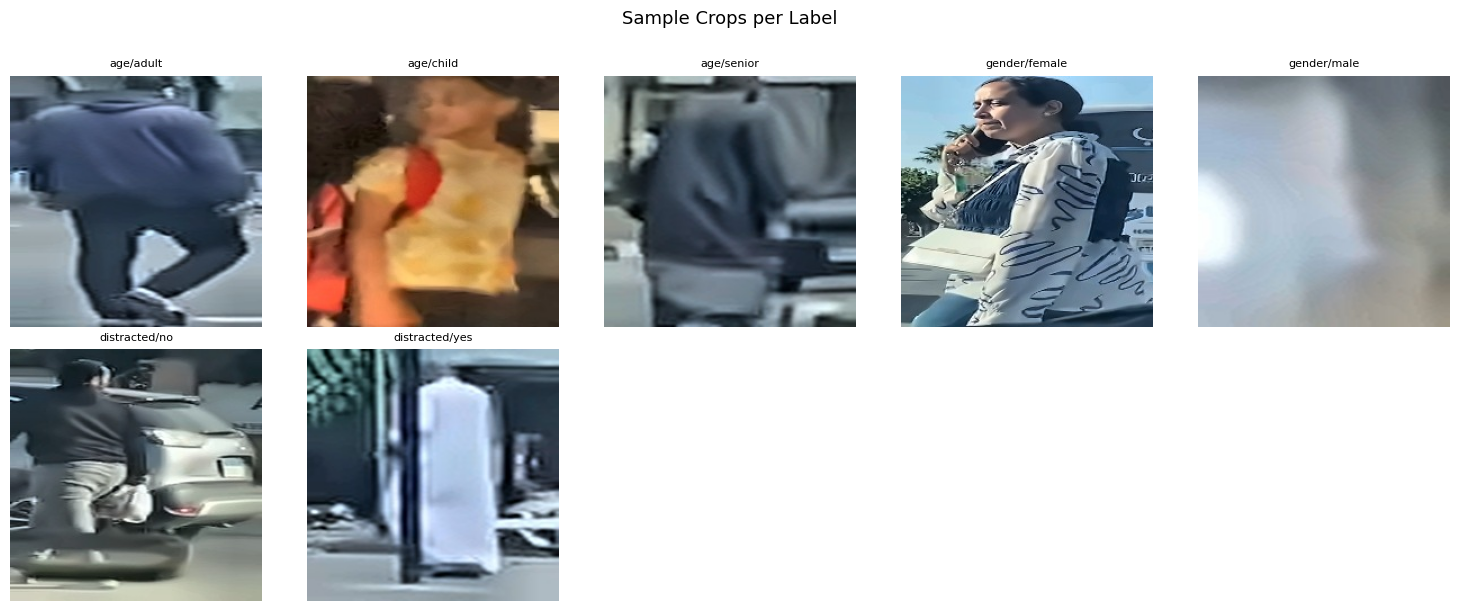

In [8]:
import matplotlib.pyplot as plt, random

print('\n Class distribution\n')
for feat in FEATURE_COLUMNS:
    fd = os.path.join(OUTPUT_ROOT, feat)
    if not os.path.isdir(fd): continue
    print(f'  {feat}:')
    for lbl in sorted(os.listdir(fd)):
        ld = os.path.join(fd, lbl)
        n  = len([f for f in os.listdir(ld) if f.endswith('.jpg')])
        print(f'    {lbl:<22} {"█"*max(1,n//30)} {n}')

samples, titles = [], []
for feat in list(FEATURE_COLUMNS)[:3]:
    fd = os.path.join(OUTPUT_ROOT, feat)
    if not os.path.isdir(fd): continue
    for lbl in sorted(os.listdir(fd)):
        ld   = os.path.join(fd, lbl)
        imgs = [os.path.join(ld,f) for f in os.listdir(ld)
                if f.endswith('.jpg') and '_aug' not in f]
        if imgs:
            samples.append(random.choice(imgs))
            titles.append(f'{feat}/{lbl}')

if samples:
    NC=5; NR=(len(samples)+NC-1)//NC
    fig,axes=plt.subplots(NR,NC,figsize=(NC*3,NR*3))
    axes=axes.flatten()
    for ax,p,t in zip(axes,samples,titles):
        ax.imshow(cv2.cvtColor(cv2.imread(p),cv2.COLOR_BGR2RGB))
        ax.set_title(t,fontsize=8); ax.axis('off')
    for ax in axes[len(samples):]: ax.axis('off')
    plt.suptitle('Sample Crops per Label',fontsize=13,y=1.01)
    plt.tight_layout(); plt.show()

##  Step 7 — EfficientNet-B2 Multi-Task Model

In [9]:
import torch, torch.nn as nn, torch.nn.functional as F, timm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


class MultiTaskEfficientNet(nn.Module):
    def __init__(self, num_classes_per_task, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b2', pretrained=True, num_classes=0)
        d = self.backbone.num_features
        self.drop  = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({
            t: nn.Sequential(nn.Linear(d,256),nn.ReLU(),nn.Dropout(dropout),nn.Linear(256,n))
            for t,n in num_classes_per_task.items()
        })

    def forward(self, x):
        f = self.drop(self.backbone(x))
        return {t: h(f) for t,h in self.heads.items()}


print(' Model defined')

Device: cpu
✅ Model defined


##  Step 8 — Dataset Loader

In [10]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

train_tf = transforms.Compose([
    transforms.Resize((240,240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


class MergedDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root=root; self.transform=transform
        self.features = sorted([d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root,d)) and not d.startswith('_')])
        self.class_to_idx={}
        for feat in self.features:
            fd=os.path.join(root,feat)
            cls=sorted([d for d in os.listdir(fd) if os.path.isdir(os.path.join(fd,d))])
            self.class_to_idx[feat]={c:i for i,c in enumerate(cls)}
        store={}
        for feat in self.features:
            for lbl in os.listdir(os.path.join(root,feat)):
                ld=os.path.join(root,feat,lbl)
                if not os.path.isdir(ld): continue
                for fname in os.listdir(ld):
                    if not fname.endswith('.jpg'): continue
                    key=fname.split('_aug')[0].replace('.jpg','')
                    if key not in store: store[key]={'_paths':{}}
                    store[key][feat]=lbl
                    store[key]['_paths'][feat]=os.path.join(ld,fname)
        self.samples=[v for v in store.values() if all(f in v for f in self.features)]
        print(f' Dataset: {len(self.samples)} samples | features: {self.features}')

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        s=self.samples[idx]
        img=Image.open(list(s['_paths'].values())[0]).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, {f:torch.tensor(self.class_to_idx[f][s[f]],dtype=torch.long)
                     for f in self.features}


full_ds=MergedDataset(OUTPUT_ROOT, transform=train_tf)
FEATURES=full_ds.features; class_to_idx=full_ds.class_to_idx

vs=max(1,int(0.2*len(full_ds))); ts=len(full_ds)-vs
train_ds,val_ds=random_split(full_ds,[ts,vs])
val_ds.dataset.transform=val_tf

train_loader=DataLoader(train_ds,batch_size=32,shuffle=True, num_workers=2,pin_memory=True)
val_loader  =DataLoader(val_ds,  batch_size=32,shuffle=False,num_workers=2,pin_memory=True)
print(f'Train={len(train_ds)} | Val={len(val_ds)}')

✅ Dataset: 3076 samples | features: ['age', 'crossed', 'distracted', 'dresscodestyle', 'fashionpersonality', 'gender', 'judgmentcalls', 'location', 'relativeposition', 'weight']
Train=2461 | Val=615


##  Step 9 — Train

In [12]:
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt

EPOCHS=25; LR=3e-4

model    =MultiTaskEfficientNet({f:len(class_to_idx[f]) for f in FEATURES}).to(device)
optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
scaler   =GradScaler()

BEST_CKPT='/content/drive/MyDrive/GIU.Master/best_model.pth'
best_val=float('inf')
t_losses,v_losses=[],[]

for ep in range(1,EPOCHS+1):
    model.train(); tl=0
    for imgs,labels in train_loader:
        imgs=imgs.to(device)
        with autocast():
            o=model(imgs)
            loss=sum(F.cross_entropy(o[f],labels[f].to(device),label_smoothing=0.1)
                     for f in FEATURES)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        tl+=loss.item()

    model.eval(); vl=0
    corr={f:0 for f in FEATURES}; tot={f:0 for f in FEATURES}
    with torch.no_grad():
        for imgs,labels in val_loader:
            imgs=imgs.to(device); o=model(imgs)
            for f in FEATURES:
                t=labels[f].to(device)
                vl+=F.cross_entropy(o[f],t).item()
                corr[f]+=(o[f].argmax(1)==t).sum().item(); tot[f]+=len(t)

    at=tl/max(1,len(train_loader)); av=vl/max(1,len(val_loader)*len(FEATURES))
    t_losses.append(at); v_losses.append(av)
    acc=' '.join(f'{f}={corr[f]/max(1,tot[f]):.1%}' for f in FEATURES)
    print(f'Ep{ep:02d}/{EPOCHS} train={at:.4f} val={av:.4f} | {acc}')

    if av<best_val:
        best_val=av
        torch.save({'model_state':model.state_dict(),
                    'class_to_idx':class_to_idx,'features':FEATURES},BEST_CKPT)
        print(f'    Best saved (val={av:.4f})')
    scheduler.step()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

/tmp/ipython-input-875061023.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler   =GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-875061023.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Ep01/25 train=3.8292 val=0.0989 | age=96.9% crossed=99.5% distracted=98.9% dresscodestyle=99.2% fashionpersonality=100.0% gender=99.7% judgmentcalls=96.3% location=98.2% relativeposition=98.9% weight=99.2%
   💾 Best saved (val=0.0989)
Ep02/25 train=2.4972 val=0.0752 | age=97.2% crossed=99.8% distracted=99.0% dresscodestyle=99.2% fashionpersonality=100.0% gender=99.3% judgmentcalls=97.1% location=100.0% relativeposition=100.0% weight=100.0%
   💾 Best saved (val=0.0752)
Ep03/25 train=2.3371 val=0.0768 | age=96.6% crossed=99.7% distracted=99.0% dresscodestyle=99.5% fashionpersonality=100.0% gender=99.3% judgmentcalls=96.6% location=100.0% relativeposition=100.0% weight=99.8%
Ep04/25 train=2.2883 val=0.0763 | age=97.4% crossed=99.7% distracted=99.8% dresscodestyle=99.3% fashionpersonality=100.0% gender=99.5% judgmentcalls=95.4% location=100.0% relativeposition=100.0% weight=100.0%
Ep05/25 train=2.2720 val=0.0688 | age=97.4% crossed=99.8% distracted=99.8% dresscodestyle=99.5% fashionpersona

KeyboardInterrupt: 

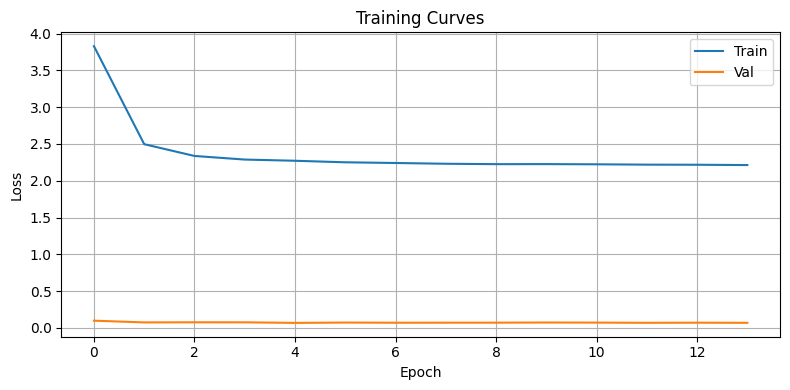

In [17]:
plt.figure(figsize=(8,4))
plt.plot(t_losses,label='Train'); plt.plot(v_losses,label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Curves')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

##  Step 10 — Video Animation with Feature Detection Overlay

In [13]:
import imageio
from torchvision import transforms
from PIL import Image

# Load best checkpoint
ckpt=torch.load(BEST_CKPT,map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(' Best model loaded')

idx2cls={f:{v:k for k,v in ckpt['class_to_idx'][f].items()} for f in ckpt['features']}

infer_tf=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

FEAT_CLR={
    'age':(255,200,0),'gender':(0,200,255),'distracted':(255,80,80),
    'crossed':(80,255,80),'judgmentCalls':(200,0,255),'relativePosition':(255,150,0),
}


@torch.no_grad()
def classify_crop(bgr):
    pil=Image.fromarray(cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB))
    t=infer_tf(pil).unsqueeze(0).to(device)
    o=model(t)
    return {f:idx2cls[f][o[f].argmax(1).item()] for f in ckpt['features']}


def draw_detections(frame, dets):
    out=frame.copy()
    for d in dets:
        x1,y1,x2,y2=d['box']
        cv2.rectangle(out,(x1,y1),(x2,y2),(0,255,0),2)
        yt=y1-5
        for feat,lbl in d['preds'].items():
            cv2.putText(out,f'{feat}: {lbl}',(x1,max(yt,14)),
                        cv2.FONT_HERSHEY_SIMPLEX,0.42,FEAT_CLR.get(feat,(255,255,255)),1,cv2.LINE_AA)
            yt-=15
    return out


def process_video(input_path, output_path,
                  start_sec=0, end_sec=None,
                  yolo_conf=0.35, max_frames=500,
                  display_inline=True):
    """
    Detect persons frame-by-frame with YOLO, classify with the trained model,
    draw coloured label boxes, save annotated MP4, show preview grid.
    """
    cap=cv2.VideoCapture(input_path)
    if not cap.isOpened(): print(f' Cannot open: {input_path}'); return

    fps=cap.get(cv2.CAP_PROP_FPS) or 25
    W=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    s_fr=int(start_sec*fps); e_fr=int(end_sec*fps) if end_sec else total
    cap.set(cv2.CAP_PROP_POS_FRAMES,s_fr)

    writer=imageio.get_writer(output_path,fps=int(fps),codec='libx264',
                               quality=7,macro_block_size=1)
    preview=[]; fi=s_fr; fc=0

    print(f' {os.path.basename(input_path)} | {start_sec}s→{end_sec or "end"}s | {W}x{H} @ {fps:.0f}fps')

    while True:
        ret,frame=cap.read()
        if not ret or fi>=e_fr or fc>=max_frames: break

        res=yolo_model(frame,verbose=False,conf=yolo_conf,classes=[0])
        dets=[]
        if res and res[0].boxes is not None:
            for d in res[0].boxes.xyxy.cpu().numpy():
                x1,y1,x2,y2=map(int,d[:4])
                x1=max(0,x1);y1=max(0,y1);x2=min(W,x2);y2=min(H,y2)
                if x2-x1<MIN_CROP_PX or y2-y1<MIN_CROP_PX: continue
                dets.append({'box':(x1,y1,x2,y2),'preds':classify_crop(frame[y1:y2,x1:x2])})

        ann=draw_detections(frame,dets)
        writer.append_data(cv2.cvtColor(ann,cv2.COLOR_BGR2RGB))

        if fc%10==0 and len(preview)<10:
            sm=cv2.resize(ann,(480,int(480*H/W)))
            preview.append(cv2.cvtColor(sm,cv2.COLOR_BGR2RGB))

        fi+=1; fc+=1

    cap.release(); writer.close()
    print(f' Saved → {output_path}  ({fc} frames)')

    if display_inline and preview:
        fig,axes=plt.subplots(2,5,figsize=(20,8))
        for ax,img in zip(axes.flatten(),preview):
            ax.imshow(img); ax.axis('off')
        for ax in axes.flatten()[len(preview):]: ax.axis('off')
        plt.suptitle(f'Preview — {os.path.basename(input_path)}',fontsize=13)
        plt.tight_layout(); plt.show()


print(' process_video() ready')

 Best model loaded
 process_video() ready


 test_video.mp4 | 0s→30s | 1920x944 @ 30fps
 Saved → /content/drive/MyDrive/GIU.Master/V1_annotated.mp4  (231 frames)


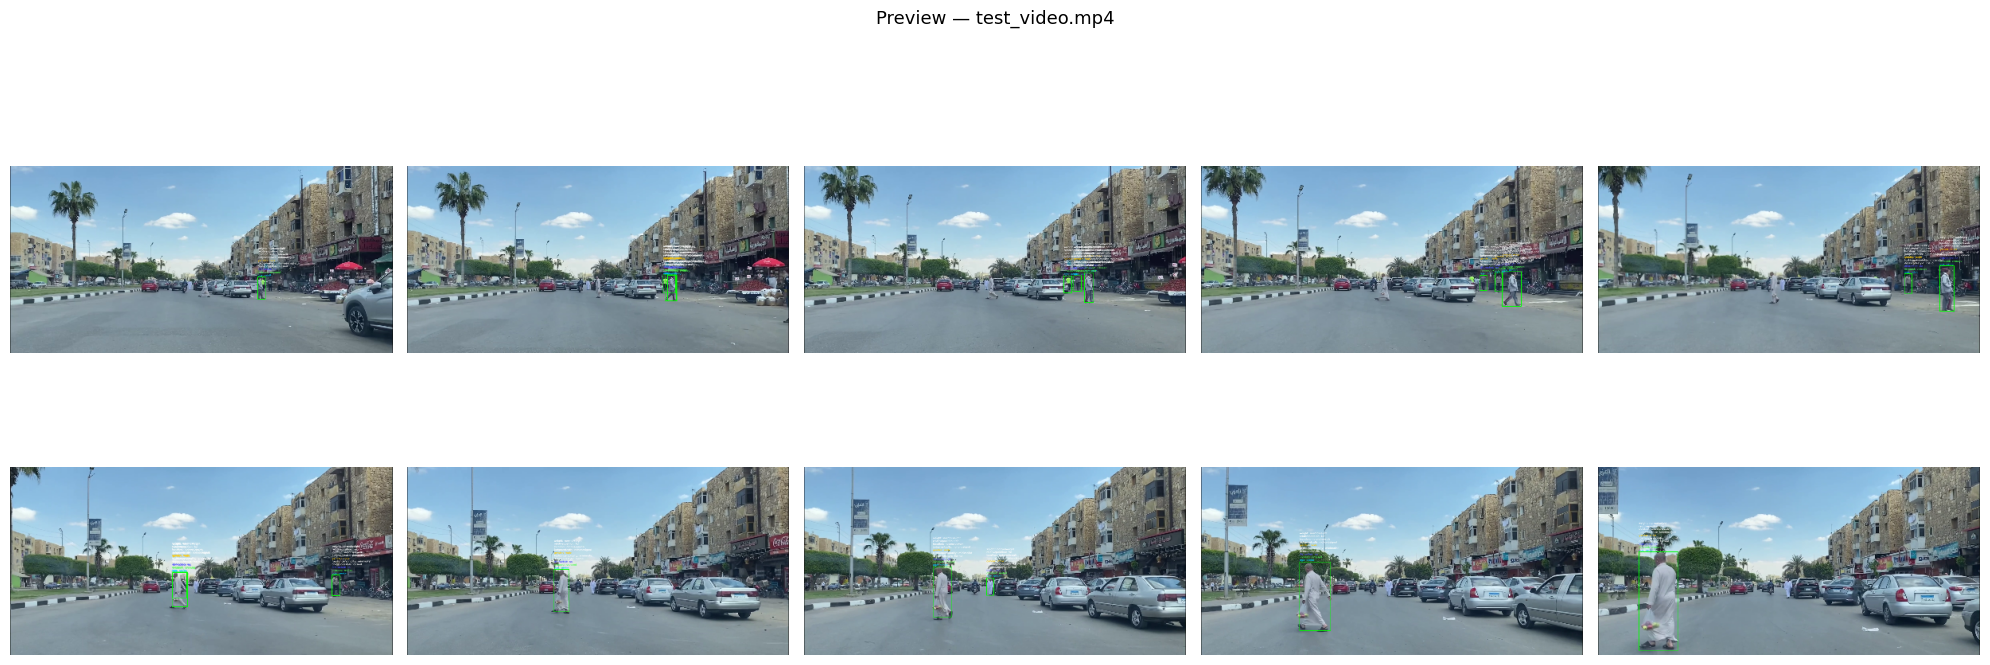

In [14]:
# ── Set your video path & timestamps, then run ────────────────────────────────
INPUT_VIDEO  = '/content/drive/MyDrive/GIU.Master/test/test_video.mp4'
OUTPUT_VIDEO = '/content/drive/MyDrive/GIU.Master/V1_annotated.mp4'

process_video(
    input_path    = INPUT_VIDEO,
    output_path   = OUTPUT_VIDEO,
    start_sec     = 0,
    end_sec       = 30,     # seconds — set None for full video
    yolo_conf     = 0.35,
    max_frames    = 600,
    display_inline= True,
)

In [18]:
# ── Set your video path & timestamps, then run ────────────────────────────────
INPUT_VIDEO  = '/content/drive/MyDrive/GIU.Master/test/test_video.mp4'
OUTPUT_VIDEO = '/content/drive/MyDrive/GIU.Master/V1_annotated.mp4'

process_video(
    input_path    = INPUT_VIDEO,
    output_path   = OUTPUT_VIDEO,
    start_sec     = 0,
    end_sec       = 30,     # seconds — set None for full video
    yolo_conf     = 0.35,
    max_frames    = 600,
    display_inline= False,
)

 test_video.mp4 | 0s→30s | 1920x944 @ 30fps
 Saved → /content/drive/MyDrive/GIU.Master/V1_annotated.mp4  (231 frames)


##  Step 11 — Single Image Inference

Testing: /content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2/gender/male/V5_t8_f912.jpg


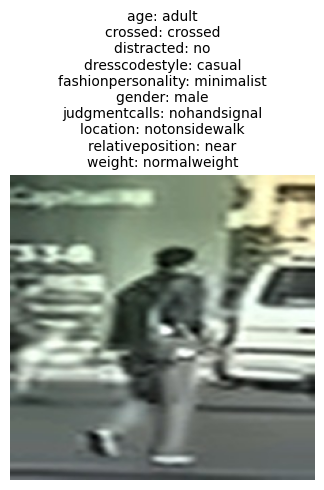

In [15]:
import random

def predict_image_file(path):
    bgr=cv2.imread(path)
    if bgr is None: print(f'Cannot read {path}'); return
    preds=classify_crop(bgr)
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('\n'.join(f'{k}: {v}' for k,v in preds.items()),fontsize=10)
    plt.tight_layout(); plt.show()
    return preds

all_imgs=[]
for feat in FEATURES:
    for lbl in os.listdir(os.path.join(OUTPUT_ROOT,feat)):
        ld=os.path.join(OUTPUT_ROOT,feat,lbl)
        if os.path.isdir(ld):
            all_imgs+=[os.path.join(ld,f) for f in os.listdir(ld)
                       if f.endswith('.jpg') and '_aug' not in f]

if all_imgs:
    pick=random.choice(all_imgs)
    print(f'Testing: {pick}')
    predict_image_file(pick)
else:
    print('No images yet — run Step 5 first')

##  Step 12 — Save Final Model

In [16]:
FINAL='/content/drive/MyDrive/GIU.Master/multi_task_efficientnet_final.pth'
torch.save({'model_state':model.state_dict(),
            'class_to_idx':class_to_idx,
            'features':FEATURES,
            'model_type':'efficientnet_b2_multitask'},FINAL)
print(f' Final model saved → {FINAL}')

 Final model saved → /content/drive/MyDrive/GIU.Master/multi_task_efficientnet_final.pth
